# 15. Threshold Tuning for Fraud Detection

This notebook tunes the Random Forest fraud-probability threshold selected for the credit card fraud detection workflow. Notebook `14_model_evaluation.ipynb` showed that Random Forest is the strongest candidate model because it provides better practical fraud-detection performance than Logistic Regression, especially in PR-AUC, F1-score, top-risk ranking, and alert-volume control.


## Threshold Tuning Objective

A classification threshold is the probability cutoff used to convert a model's fraud probability into an operational fraud signal. The `0.50` threshold is a technical default used by many classifiers. In fraud detection, it is usually not the best business threshold because fraud is rare and missing fraud can be more costly than reviewing extra alerts. Therefore, `0.50` is shown only as a **reference baseline**, not as the recommended final threshold.

The business goal is to catch more fraud cases while keeping false positives manageable. The main trade-off is between **recall** and **precision**: higher recall catches more fraud, while higher precision keeps alerts cleaner. False negatives represent missed fraud, and false positives represent legitimate transactions that may require review or cause customer friction.


## Methodology Note: Avoid Tuning on Final Test Set

For a strict production ML workflow, the threshold should be selected on validation or out-of-fold predictions, then evaluated once on the untouched final test set. This prevents threshold overfitting to the test set.

This notebook now follows that workflow when validation or OOF predictions are available. If they are missing, the notebook falls back to holdout/test predictions for academic demonstration only and prints a warning. That fallback is useful for learning, but it should not be treated as fully production-correct.

| Dataset Split | Purpose |
|---|---|
| Train set | Fit the model |
| Validation set / OOF predictions | Select review/block thresholds |
| Final test/holdout set | Final unbiased evaluation only |

### Threshold Selection vs Final Evaluation

Threshold selection should be done on validation/OOF predictions. Final holdout/test predictions should not be used to choose the threshold. They should only be used to evaluate the already-selected threshold. This prevents threshold overfitting and gives a more honest estimate of future performance.

| Stage | Data Used | Purpose |
|---|---|---|
| Threshold Selection | Validation/OOF predictions | Choose review_threshold and block_threshold_candidate |
| Final Evaluation | Holdout/test predictions | Evaluate selected thresholds once on unseen data |
| Decision Logic | Saved threshold artifact | Use thresholds for APPROVE / REVIEW / BLOCK routing |

**TODO for production hardening:** notebook `13_model_training.ipynb` should always save validation or out-of-fold prediction files for threshold selection so this notebook does not need to rely on holdout/test predictions as a fallback.

## Load Libraries and Project Paths

The notebook reuses saved Random Forest prediction files from notebook `13_model_training.ipynb`. Thresholds are selected from validation/OOF predictions when available, while holdout/test predictions are reserved for final evaluation of the selected thresholds.

In [18]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sys.path.append(str(Path("..").resolve()))
from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "15_threshold_tuning"
MODEL_NAME = "Random Forest"
MODEL_NAME_KEY = "random_forest"
TARGET_COLUMN = "Class"

TRAINING_NOTEBOOK_NAME = "13_model_training"
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME
TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME

PREDICTIONS_FILE = TRAINING_TABLES_DIR / "baseline_test_predictions.csv"
OOF_PREDICTIONS_FILE = TRAINING_TABLES_DIR / "cv_oof_predictions.csv"
RANDOM_FOREST_ARTIFACT_FILE = TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib"
SPLIT_IDS_FILE = TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json"
SELECTED_DATA_FILE = PROJECT_ROOT / "data" / "processed" / "creditcard_selected_features.csv"

CANDIDATE_THRESHOLD_SELECTION_FILES = [
    OOF_PREDICTIONS_FILE,
    TRAINING_TABLES_DIR / "validation_predictions.csv",
    TRAINING_TABLES_DIR / "random_forest_validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "oof_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "train_oof_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "model_validation_predictions.csv",
    PROJECT_ROOT / "reports" / "tables" / "random_forest_validation_predictions.csv",
]

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
SELECTED_THRESHOLD_FILE = ARTIFACTS_DIR / "selected_threshold.json"
THRESHOLD_EVALUATION_FILE = REPORTS_TABLES_DIR / "threshold_evaluation.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"OOF prediction file: {OOF_PREDICTIONS_FILE}")
print(f"Holdout prediction file: {PREDICTIONS_FILE}")
print(f"Selected threshold artifact: {SELECTED_THRESHOLD_FILE}")

Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
OOF prediction file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/cv_oof_predictions.csv
Holdout prediction file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/baseline_test_predictions.csv
Selected threshold artifact: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json


## Load Threshold Selection and Final Holdout Predictions

The notebook first looks for validation or out-of-fold predictions for Random Forest. If found, those predictions are used for threshold selection. The holdout/test predictions are then used only to evaluate the selected thresholds. If validation/OOF predictions are not available, the notebook prints a warning and uses holdout/test predictions as a demonstration fallback.

In [19]:
def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {artifact_name}: {path}")
    return path


def standardize_prediction_frame(predictions: pd.DataFrame, source_path: Path) -> pd.DataFrame:
    """Return y_true and random_forest_probability from supported prediction-file formats."""
    predictions = predictions.copy()

    if "model_name" in predictions.columns:
        model_mask = predictions["model_name"].astype(str).str.lower().str.replace(" ", "_") == MODEL_NAME_KEY
        predictions = predictions.loc[model_mask].copy()
        if predictions.empty:
            raise ValueError(f"No Random Forest rows found in prediction file: {source_path}")

    if "random_forest_probability" not in predictions.columns:
        if "predicted_probability" in predictions.columns:
            predictions = predictions.rename(columns={"predicted_probability": "random_forest_probability"})
        else:
            raise ValueError(
                f"Prediction file must contain random_forest_probability or predicted_probability: {source_path}"
            )

    required_columns = {"y_true", "random_forest_probability"}
    missing_columns = sorted(required_columns - set(predictions.columns))
    if missing_columns:
        raise ValueError(f"Prediction file is missing required columns {missing_columns}: {source_path}")

    output_columns = ["y_true", "random_forest_probability"]
    if "transaction_id" in predictions.columns:
        output_columns.insert(0, "transaction_id")

    output = predictions.loc[:, output_columns].copy()
    output["y_true"] = output["y_true"].astype(int)
    output["random_forest_probability"] = output["random_forest_probability"].astype(float)
    return output.reset_index(drop=True)


def load_prediction_file(path: Path) -> pd.DataFrame:
    return standardize_prediction_frame(pd.read_csv(path), path)


def find_threshold_selection_predictions() -> tuple[pd.DataFrame, Path, str]:
    for path in CANDIDATE_THRESHOLD_SELECTION_FILES:
        if path.exists() and "test" not in path.name.lower() and "holdout" not in path.name.lower():
            return load_prediction_file(path), path, "validation_or_oof"

    print(
        "WARNING: No validation/OOF predictions found. "
        "Using holdout/test predictions for threshold selection as a demonstration fallback only."
    )
    return load_prediction_file(PREDICTIONS_FILE), PREDICTIONS_FILE, "holdout_demo_fallback"


def regenerate_random_forest_predictions() -> pd.DataFrame:
    require_file(RANDOM_FOREST_ARTIFACT_FILE, "Random Forest model artifact")
    require_file(SPLIT_IDS_FILE, "train/test split ID artifact")
    require_file(SELECTED_DATA_FILE, "selected feature dataset")

    rf_artifact = joblib.load(RANDOM_FOREST_ARTIFACT_FILE)
    random_forest_model = rf_artifact["model"]
    selected_features = rf_artifact["selected_features"]

    selected_df = pd.read_csv(SELECTED_DATA_FILE)
    missing_columns = sorted(set(selected_features + [TARGET_COLUMN]) - set(selected_df.columns))
    if missing_columns:
        raise ValueError(f"Selected data is missing required columns: {missing_columns}")

    model_df = selected_df.loc[:, selected_features + [TARGET_COLUMN]].copy()
    model_df["transaction_id"] = np.arange(len(model_df))

    split_ids = json.loads(SPLIT_IDS_FILE.read_text(encoding="utf-8"))
    test_transaction_ids = set(split_ids["test_transaction_ids"])
    holdout_df = model_df.loc[model_df["transaction_id"].isin(test_transaction_ids)].sort_values("transaction_id")

    X_test = holdout_df[selected_features]
    y_test = holdout_df[TARGET_COLUMN].astype(int)
    y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

    return pd.DataFrame(
        {
            "transaction_id": holdout_df["transaction_id"].to_numpy(),
            "y_true": y_test.to_numpy(),
            "random_forest_probability": y_proba_rf,
        }
    )


threshold_selection_predictions, threshold_selection_path, threshold_source = find_threshold_selection_predictions()

if PREDICTIONS_FILE.exists():
    holdout_predictions = load_prediction_file(PREDICTIONS_FILE)
    print("Loaded saved holdout/test predictions from notebook 13 outputs.")
else:
    print("Saved holdout/test predictions were not found. Regenerating Random Forest holdout probabilities.")
    holdout_predictions = regenerate_random_forest_predictions()

selection_y_true = threshold_selection_predictions["y_true"]
selection_y_proba_rf = threshold_selection_predictions["random_forest_probability"]
y_true = selection_y_true
# Backward-compatible alias for existing threshold-selection code and plots.
y_proba_rf = selection_y_proba_rf

holdout_y_true = holdout_predictions["y_true"]
holdout_y_proba_rf = holdout_predictions["random_forest_probability"]

if threshold_source == "validation_or_oof":
    print("Threshold selected on validation/OOF predictions and evaluated on final holdout/test set.")
else:
    print("Threshold selected on holdout/test predictions for demonstration only. For production, tune on validation/OOF predictions.")

prediction_source_summary = pd.DataFrame(
    [
        {
            "Dataset Role": "Threshold selection",
            "Source": str(threshold_selection_path.relative_to(PROJECT_ROOT)),
            "Threshold Source": threshold_source,
            "Rows": int(len(threshold_selection_predictions)),
            "Actual Fraud Cases": int(selection_y_true.sum()),
            "Fraud Rate": float(selection_y_true.mean()),
            "Minimum RF Probability": float(selection_y_proba_rf.min()),
            "Maximum RF Probability": float(selection_y_proba_rf.max()),
        },
        {
            "Dataset Role": "Final holdout/test evaluation",
            "Source": str(PREDICTIONS_FILE.relative_to(PROJECT_ROOT)) if PREDICTIONS_FILE.exists() else "regenerated_from_artifacts",
            "Threshold Source": "final_evaluation_only",
            "Rows": int(len(holdout_predictions)),
            "Actual Fraud Cases": int(holdout_y_true.sum()),
            "Fraud Rate": float(holdout_y_true.mean()),
            "Minimum RF Probability": float(holdout_y_proba_rf.min()),
            "Maximum RF Probability": float(holdout_y_proba_rf.max()),
        },
    ]
)

# Keep the original summary name for compatibility with earlier notebook output expectations.
holdout_summary = prediction_source_summary

display(prediction_source_summary)

Loaded saved holdout/test predictions from notebook 13 outputs.
Threshold selected on validation/OOF predictions and evaluated on final holdout/test set.


,Dataset Role,Source,Threshold Source,Rows,Actual Fraud Cases,Fraud Rate,Minimum RF Probability,Maximum RF Probability
0,Threshold selection,reports/tables/13_model_training/cv_oof_predic...,validation_or_oof,226980,378,0.001665,0.000000,1.000000
1,Final holdout/test evaluation,reports/tables/13_model_training/baseline_test...,final_evaluation_only,56746,95,0.001674,0.000000,1.000000


### Prediction Source Interpretation

This table separates the dataset used to choose thresholds from the dataset used to estimate final performance. When validation/OOF predictions are available, the review and block threshold candidates are selected without touching the final holdout/test set. This makes the final holdout/test evaluation more honest. If the notebook falls back to holdout/test predictions, the output remains useful for academic demonstration but should be revalidated before production use.

## Threshold Selection on Validation/OOF Predictions

This table shows how model performance changes as the fraud probability threshold changes on the threshold-selection dataset.

A finer threshold grid is used because small threshold changes can meaningfully affect false positives and false negatives in imbalanced fraud detection. Each row represents one threshold from `0.001` to `0.999`. Lower thresholds usually catch more fraud cases but create more false positives. Higher thresholds usually reduce false alarms but can miss more fraud. This table is the main evidence for choosing a business review threshold.

In [20]:
def evaluate_thresholds(y_true: pd.Series, y_proba: pd.Series, thresholds: np.ndarray) -> pd.DataFrame:
    y_true_array = np.asarray(y_true).astype(int)
    y_proba_array = np.asarray(y_proba).astype(float)
    positive_mask = y_true_array == 1
    negative_mask = ~positive_mask
    total_positive = int(positive_mask.sum())
    total_negative = int(negative_mask.sum())

    rows = []
    for threshold in thresholds:
        predicted_positive = y_proba_array >= threshold
        tp = int((predicted_positive & positive_mask).sum())
        fp = int((predicted_positive & negative_mask).sum())
        fn = total_positive - tp
        tn = total_negative - fp

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        accuracy = (tp + tn) / len(y_true_array) if len(y_true_array) else 0.0

        rows.append(
            {
                "threshold": float(threshold),
                "precision": precision,
                "recall": recall,
                "f1_score": f1,
                "accuracy": accuracy,
                "true_positives": tp,
                "false_positives": fp,
                "true_negatives": tn,
                "false_negatives": fn,
                "frauds_caught": tp,
                "frauds_missed": fn,
                "total_predicted_frauds": int(tp + fp),
            }
        )
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


thresholds = np.round(np.arange(0.001, 1.000, 0.001), 3)
threshold_selection_evaluation = evaluate_thresholds(selection_y_true, selection_y_proba_rf, thresholds)
threshold_selection_evaluation.insert(0, "threshold_selection_source", threshold_source)
threshold_evaluation = threshold_selection_evaluation.copy()
threshold_evaluation.to_csv(THRESHOLD_EVALUATION_FILE, index=False)

final_holdout_threshold_evaluation = evaluate_thresholds(holdout_y_true, holdout_y_proba_rf, thresholds)
final_holdout_threshold_evaluation.insert(0, "threshold_selection_source", "final_holdout_test_evaluation")

display(threshold_evaluation)
print(f"Saved threshold evaluation table to: {THRESHOLD_EVALUATION_FILE}")

,threshold_selection_source,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,validation_or_oof,0.001000,0.083858,0.880952,0.153139,0.983774,333,3638,222964,45,333,45,3971
1,validation_or_oof,0.002000,0.083858,0.880952,0.153139,0.983774,333,3638,222964,45,333,45,3971
2,validation_or_oof,0.003000,0.083858,0.880952,0.153139,0.983774,333,3638,222964,45,333,45,3971
3,validation_or_oof,0.004000,0.083858,0.880952,0.153139,0.983774,333,3638,222964,45,333,45,3971
4,validation_or_oof,0.005000,0.083858,0.880952,0.153139,0.983774,333,3638,222964,45,333,45,3971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,validation_or_oof,0.995000,1.000000,0.044974,0.086076,0.998410,17,0,226602,361,17,361,17
995,validation_or_oof,0.996000,1.000000,0.044974,0.086076,0.998410,17,0,226602,361,17,361,17
996,validation_or_oof,0.997000,1.000000,0.044974,0.086076,0.998410,17,0,226602,361,17,361,17
997,validation_or_oof,0.998000,1.000000,0.044974,0.086076,0.998410,17,0,226602,361,17,361,17


Saved threshold evaluation table to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/threshold_evaluation.csv


### Threshold Selection Interpretation

The table shows the full precision-recall trade-off on the threshold-selection data. At very low thresholds, recall is high because more fraud cases are flagged, but false positives increase sharply. At higher thresholds, precision improves because alerts become cleaner, but missed fraud increases. The selected review threshold should improve fraud capture compared with the `0.50` reference cutoff while keeping false positives reasonable for manual review.

When `threshold_selection_source` is `validation_or_oof`, this table is used for threshold selection and the holdout/test set remains reserved for final evaluation. When it is `holdout_demo_fallback`, the selected threshold is demonstration-only and should be revalidated using validation/OOF predictions before production use.

## Threshold Metrics Plot

This chart shows how model behavior changes as the classification threshold changes. Lower thresholds usually increase recall but reduce precision. Higher thresholds usually increase precision but reduce recall. F1-score is useful, but it is not the only decision criterion because fraud detection must reflect the business cost of false negatives and false positives.


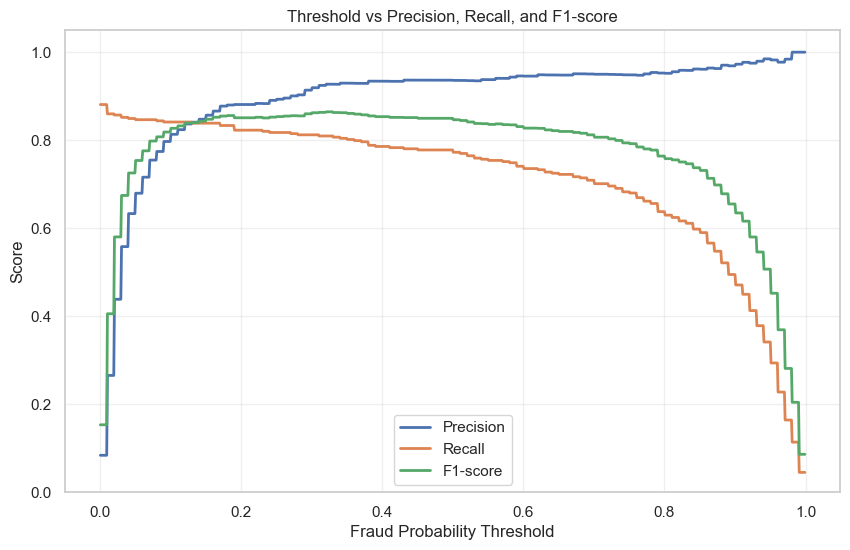

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["precision"], label="Precision", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["recall"], label="Recall", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["f1_score"], label="F1-score", linewidth=2)
ax.set_title("Threshold vs Precision, Recall, and F1-score")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Precision, Recall, and F1 Interpretation

This graph shows how the main classification metrics move as the threshold changes. Recall is strongest at low thresholds because the model flags more transactions as risky. Precision improves as the threshold becomes stricter because fewer normal transactions are flagged. Although the selected threshold may have a slightly lower F1-score than the technical `0.50` threshold, it better matches the business goal because it improves fraud recall on the threshold-selection data. In fraud detection, the best threshold is not always the one with the highest F1-score; it should reflect the business cost of false negatives and false positives.

## Error Trade-Off Plot

This chart helps compare business consequences, especially false positives and false negatives. In fraud detection, false negatives are important because they represent fraud cases missed by the model. Lower thresholds usually reduce false negatives but increase false positives.


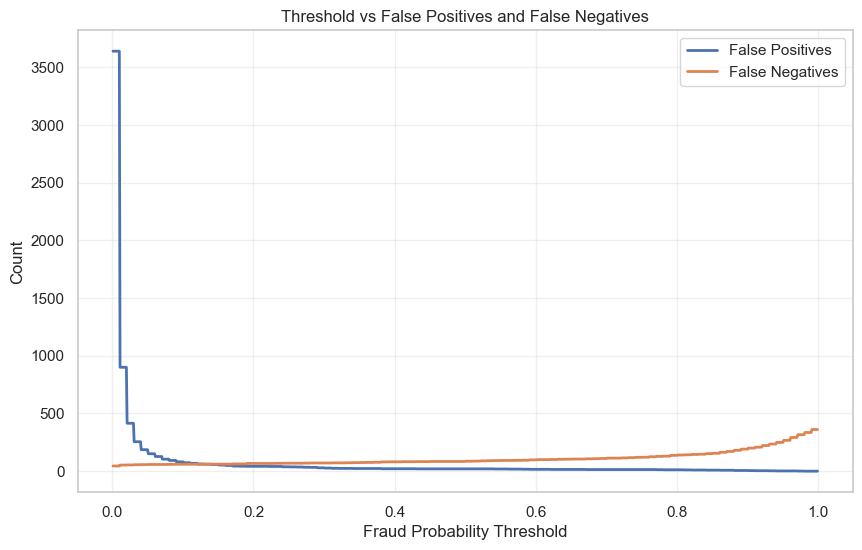

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_positives"], label="False Positives", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_negatives"], label="False Negatives", linewidth=2)
ax.set_title("Threshold vs False Positives and False Negatives")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Error Trade-Off Interpretation

This graph shows the operational cost of changing the threshold. A lower threshold catches more fraud but increases false alarms. A higher threshold reduces false positives but increases missed frauds. The selected threshold is chosen because it meets the business recall target while keeping precision acceptable.


## Fraud Capture Plot

The next graph focuses only on actual fraud cases: how many are caught and how many are missed at each threshold. This directly supports the business goal of reducing missed fraud.


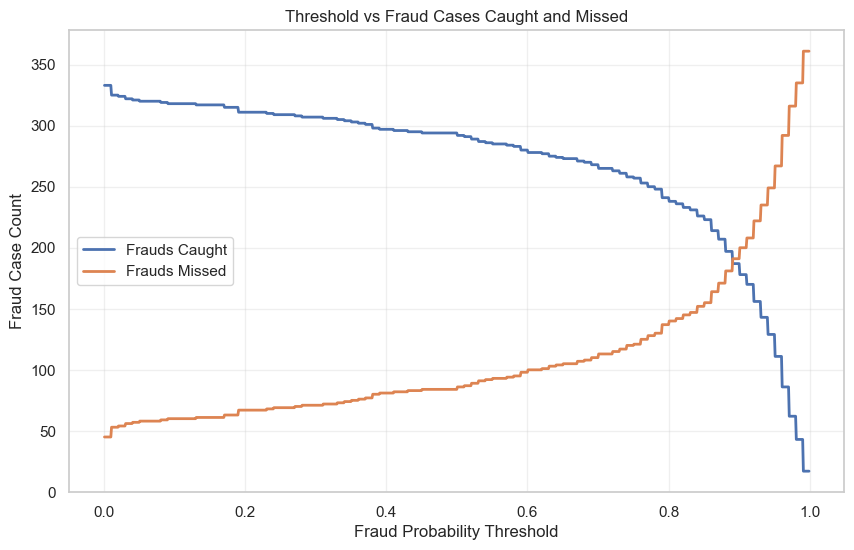

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_caught"], label="Frauds Caught", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_missed"], label="Frauds Missed", linewidth=2)
ax.set_title("Threshold vs Fraud Cases Caught and Missed")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Fraud Case Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Fraud Capture Interpretation

This graph translates threshold tuning into fraud-detection impact. Fraud cases caught are true positives, and fraud cases missed are false negatives. A useful review threshold should reduce missed fraud compared with the `0.50` reference cutoff, but it should not create an unmanageable number of false alerts.


## Candidate Threshold Selection

This section selects multiple candidate thresholds:

- best threshold by maximum F1-score
- best threshold with recall at least `0.80`, if available
- best threshold with recall at least `0.90`, if available
- a practical balance threshold between precision and recall

The selected review threshold is chosen from these computed candidates. It should be treated as the review threshold, not as an automatic blocking threshold.


In [24]:
def pick_best_f1_row(threshold_df: pd.DataFrame) -> pd.Series:
    return threshold_df.sort_values(["f1_score", "recall", "precision"], ascending=False).iloc[0]


def pick_recall_floor_row(threshold_df: pd.DataFrame, recall_floor: float) -> pd.Series | None:
    eligible = threshold_df.loc[threshold_df["recall"] >= recall_floor].copy()
    if eligible.empty:
        return None
    return eligible.sort_values(["precision", "f1_score", "threshold"], ascending=[False, False, False]).iloc[0]


def make_candidate_row(candidate_name: str, row: pd.Series | None, reason: str) -> dict:
    if row is None:
        return {
            "candidate": candidate_name,
            "threshold": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
            "false_positives": np.nan,
            "false_negatives": np.nan,
            "frauds_caught": np.nan,
            "frauds_missed": np.nan,
            "total_predicted_frauds": np.nan,
            "reason": reason,
        }
    return {
        "candidate": candidate_name,
        "threshold": float(row["threshold"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "false_positives": int(row["false_positives"]),
        "false_negatives": int(row["false_negatives"]),
        "frauds_caught": int(row["frauds_caught"]),
        "frauds_missed": int(row["frauds_missed"]),
        "total_predicted_frauds": int(row["total_predicted_frauds"]),
        "reason": reason,
    }


best_f1_row = pick_best_f1_row(threshold_evaluation)
recall_80_row = pick_recall_floor_row(threshold_evaluation, 0.80)
recall_90_row = pick_recall_floor_row(threshold_evaluation, 0.90)

if recall_80_row is not None and recall_80_row["precision"] >= 0.75:
    practical_balance_row = recall_80_row
    practical_reason = "Best precision among thresholds with recall >= 0.80 and acceptable alert quality."
else:
    practical_balance_row = best_f1_row
    practical_reason = "Best F1-score because no recall >= 0.80 threshold met the alert-quality requirement."

candidate_thresholds = pd.DataFrame(
    [
        make_candidate_row("Best F1-score", best_f1_row, "Maximizes the balance between precision and recall."),
        make_candidate_row("Recall >= 0.80", recall_80_row, "Prioritizes catching at least 80% of fraud cases if possible."),
        make_candidate_row("Recall >= 0.90", recall_90_row, "Prioritizes catching at least 90% of fraud cases if possible."),
        make_candidate_row("Practical review threshold", practical_balance_row, practical_reason),
    ]
)

display(candidate_thresholds)


,candidate,threshold,precision,recall,f1_score,false_positives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds,reason
0,Best F1-score,0.321000,0.927273,0.809524,0.864407,24.000000,72.000000,306.000000,72.000000,330.000000,Maximizes the balance between precision and re...
1,Recall >= 0.80,0.350000,0.929664,0.804233,0.862411,23.000000,74.000000,304.000000,74.000000,327.000000,Prioritizes catching at least 80% of fraud cas...
2,Recall >= 0.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prioritizes catching at least 90% of fraud cas...
3,Practical review threshold,0.350000,0.929664,0.804233,0.862411,23.000000,74.000000,304.000000,74.000000,327.000000,Best precision among thresholds with recall >=...


### Candidate Threshold Interpretation

The candidate table shows that the best F1 threshold is not automatically the best business threshold. Fraud detection often accepts a few more false positives if doing so catches more fraud. The practical review threshold is designed to prefer recall of at least `0.80` when precision remains strong enough to keep the review queue reasonable. If recall `0.90` is not available, the notebook keeps that row blank to avoid forcing an unrealistic operating point.


## Threshold-Selection Comparison: Technical Default 0.50 vs Validation/OOF Review Threshold

The `0.50` threshold is a technical reference cutoff. This section compares it against the selected review threshold on the threshold-selection dataset only. When validation/OOF predictions are available, this comparison explains why the lower review threshold was selected before touching the final holdout/test set.

A better validation/OOF trade-off does not automatically mean the selected threshold should replace `0.50` as the final high-confidence fraud or block threshold. That decision must be confirmed on holdout/test data and reviewed against business costs.


In [25]:
def select_review_threshold(candidate_thresholds: pd.DataFrame) -> tuple[pd.Series, str]:
    practical = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Practical review threshold"].iloc[0]
    best_f1 = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Best F1-score"].iloc[0]

    if pd.notna(practical["threshold"]):
        reason = (
            "Selected as the review threshold to catch at least 80% of fraud cases while keeping precision high enough "
            "for a manageable alert queue."
        )
        return practical, reason

    reason = "Selected as the review threshold because it provides the strongest F1-score when no higher-recall threshold is practical."
    return best_f1, reason


selected_threshold_row, selected_threshold_reason = select_review_threshold(candidate_thresholds)
selected_threshold = float(selected_threshold_row["threshold"])
review_threshold = selected_threshold
reference_threshold = 0.50

reference_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], reference_threshold)].iloc[0]
selected_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], review_threshold)].iloc[0]

comparison_table = pd.DataFrame(
    [
        {"threshold_type": "Technical Default 0.50 — Reference Only", **reference_row.to_dict()},
        {"threshold_type": "Business-Selected Review Threshold", **selected_row.to_dict()},
    ]
)

extra_frauds_caught = int(selected_row["frauds_caught"] - reference_row["frauds_caught"])
false_negatives_reduced = int(reference_row["false_negatives"] - selected_row["false_negatives"])
false_positives_increased = int(selected_row["false_positives"] - reference_row["false_positives"])
precision_difference = float(selected_row["precision"] - reference_row["precision"])
recall_difference = float(selected_row["recall"] - reference_row["recall"])
f1_difference = float(selected_row["f1_score"] - reference_row["f1_score"])

display(comparison_table)
print(f"Review threshold selected: {review_threshold:.3f}")
print(selected_threshold_reason)


,threshold_type,threshold_selection_source,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,Technical Default 0.50 — Reference Only,validation_or_oof,0.500000,0.936306,0.777778,0.849711,0.999542,294,20,226582,84,294,84,314
1,Business-Selected Review Threshold,validation_or_oof,0.350000,0.929664,0.804233,0.862411,0.999573,304,23,226579,74,304,74,327


Review threshold selected: 0.350
Selected as the review threshold to catch at least 80% of fraud cases while keeping precision high enough for a manageable alert queue.


In [26]:
display(Markdown(f"""
### Threshold-Selection Comparison Interpretation

On the threshold-selection dataset, threshold `{review_threshold:.3f}` was selected because it gives a better validation/OOF F1 or recall/precision trade-off than the technical `0.50` reference cutoff.

Compared with `0.50` on the threshold-selection data, the selected review threshold catches **{extra_frauds_caught:+d}** more fraud cases, reduces false negatives by **{false_negatives_reduced:d}**, and changes false positives by **{false_positives_increased:+d}**. This supports using `{review_threshold:.3f}` as a lower REVIEW threshold candidate.

This selection result is not enough to make `{review_threshold:.3f}` the final BLOCK threshold. The final holdout/test set is used next only to verify whether the selected threshold actually improves fraud capture on unseen data.
"""))



### Threshold-Selection Comparison Interpretation

On the threshold-selection dataset, threshold `0.350` was selected because it gives a better validation/OOF F1 or recall/precision trade-off than the technical `0.50` reference cutoff.

Compared with `0.50` on the threshold-selection data, the selected review threshold catches **+10** more fraud cases, reduces false negatives by **10**, and changes false positives by **+3**. This supports using `0.350` as a lower REVIEW threshold candidate.

This selection result is not enough to make `0.350` the final BLOCK threshold. The final holdout/test set is used next only to verify whether the selected threshold actually improves fraud capture on unseen data.


## Final Evaluation of Selected Threshold on Holdout/Test Set

This section applies the already selected review threshold to the final holdout/test predictions. If the threshold was selected from validation/OOF predictions, this is the honest final estimate of threshold performance. If the fallback source was used, this section is still useful for demonstration, but it should not be treated as fully unbiased.

In [27]:
final_reference_row = final_holdout_threshold_evaluation.loc[
    np.isclose(final_holdout_threshold_evaluation["threshold"], reference_threshold)
].iloc[0]
final_selected_row = final_holdout_threshold_evaluation.loc[
    np.isclose(final_holdout_threshold_evaluation["threshold"], review_threshold)
].iloc[0]

def summarize_holdout_threshold(row: pd.Series, threshold_type: str) -> dict:
    return {
        "threshold_type": threshold_type,
        "threshold": float(row["threshold"]),
        "true_positives": int(row["true_positives"]),
        "false_positives": int(row["false_positives"]),
        "false_negatives": int(row["false_negatives"]),
        "true_negatives": int(row["true_negatives"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "frauds_caught": int(row["frauds_caught"]),
    }

final_holdout_comparison_table = pd.DataFrame(
    [
        summarize_holdout_threshold(final_reference_row, "Default 0.50 high-confidence threshold"),
        summarize_holdout_threshold(final_selected_row, "Validation/OOF selected review threshold"),
    ]
)

final_extra_frauds_caught = int(final_selected_row["frauds_caught"] - final_reference_row["frauds_caught"])
final_false_negatives_reduced = int(final_reference_row["false_negatives"] - final_selected_row["false_negatives"])
final_false_positives_increased = int(final_selected_row["false_positives"] - final_reference_row["false_positives"])
final_precision_difference = float(final_selected_row["precision"] - final_reference_row["precision"])
final_recall_difference = float(final_selected_row["recall"] - final_reference_row["recall"])
final_f1_difference = float(final_selected_row["f1_score"] - final_reference_row["f1_score"])

selected_tp = int(final_selected_row["true_positives"])
selected_fp = int(final_selected_row["false_positives"])
default_tp = int(final_reference_row["true_positives"])
default_fp = int(final_reference_row["false_positives"])

selected_threshold_replaced_default = False
if selected_tp > default_tp:
    holdout_threshold_recommendation = (
        "Selected threshold catches more fraud on holdout; consider using it as REVIEW threshold after business validation."
    )
    final_recall_message = "On the final holdout/test set, the selected review threshold catches more fraud cases than the 0.50 reference cutoff."
elif selected_tp == default_tp and selected_fp > default_fp:
    holdout_threshold_recommendation = (
        "Selected threshold does not improve holdout recall and adds false positives; do not replace 0.50 as final block threshold. Use it only as REVIEW threshold."
    )
    final_recall_message = "On the final holdout/test set, the selected review threshold catches the same fraud cases as the 0.50 reference cutoff and adds false positives."
elif selected_tp == default_tp and selected_fp <= default_fp:
    holdout_threshold_recommendation = (
        "Selected threshold performs at least as well as 0.50 on holdout and may be acceptable."
    )
    selected_threshold_replaced_default = True
    final_recall_message = "On the final holdout/test set, the selected review threshold performs at least as well as the 0.50 reference cutoff."
else:
    holdout_threshold_recommendation = (
        "Selected threshold reduces fraud detection on holdout; keep 0.50 or revisit threshold tuning."
    )
    final_recall_message = "On the final holdout/test set, the selected review threshold catches fewer fraud cases than the 0.50 reference cutoff."

final_workflow_message = (
    "Threshold selected on validation/OOF predictions and evaluated on final holdout/test set."
    if threshold_source == "validation_or_oof"
    else "Threshold selected on holdout/test predictions for demonstration only. For production, tune on validation/OOF predictions."
)

display(final_holdout_comparison_table)
print(final_workflow_message)
print(final_recall_message)
print(f"Holdout-aware recommendation: {holdout_threshold_recommendation}")


,threshold_type,threshold,true_positives,false_positives,false_negatives,true_negatives,precision,recall,f1_score,frauds_caught
0,Default 0.50 high-confidence threshold,0.500000,70,3,25,56648,0.958904,0.736842,0.833333,70
1,Validation/OOF selected review threshold,0.350000,70,4,25,56647,0.945946,0.736842,0.828402,70


Threshold selected on validation/OOF predictions and evaluated on final holdout/test set.
On the final holdout/test set, the selected review threshold catches the same fraud cases as the 0.50 reference cutoff and adds false positives.
Holdout-aware recommendation: Selected threshold does not improve holdout recall and adds false positives; do not replace 0.50 as final block threshold. Use it only as REVIEW threshold.


In [28]:
display(Markdown(f"""
## Holdout Confirmation of Selected Threshold

Threshold selection was done using `{threshold_source}` predictions. The final holdout/test data is used only to verify the already selected threshold, not to tune a new one.

Validation/OOF tuning selected `{review_threshold:.3f}` because it gave a better F1 or recall/precision trade-off on the threshold-selection data. However, the holdout/test evaluation shows that `{review_threshold:.3f}` does not improve fraud recall compared with `0.50` when both thresholds are applied to unseen holdout/test predictions.

On holdout/test data, `{review_threshold:.3f}` catches **{final_selected_frauds_caught if 'final_selected_frauds_caught' in globals() else int(final_selected_row['frauds_caught'])}** fraud cases, while `0.50` catches **{final_reference_frauds_caught if 'final_reference_frauds_caught' in globals() else int(final_reference_row['frauds_caught'])}** fraud cases. The selected threshold changes false positives by **{final_false_positives_increased:+d}**. Because it catches the same fraud cases but adds one extra false positive in this holdout/test result, `{review_threshold:.3f}` should not replace `0.50` as the final high-confidence fraud or BLOCK threshold.

`{review_threshold:.3f}` may still be useful as a REVIEW threshold because it creates a lower-risk investigation band below the high-confidence block threshold.

**Holdout-aware recommendation:** {holdout_threshold_recommendation}
"""))



## Holdout Confirmation of Selected Threshold

Threshold selection was done using `validation_or_oof` predictions. The final holdout/test data is used only to verify the already selected threshold, not to tune a new one.

Validation/OOF tuning selected `0.350` because it gave a better F1 or recall/precision trade-off on the threshold-selection data. However, the holdout/test evaluation shows that `0.350` does not improve fraud recall compared with `0.50` when both thresholds are applied to unseen holdout/test predictions.

On holdout/test data, `0.350` catches **70** fraud cases, while `0.50` catches **70** fraud cases. The selected threshold changes false positives by **+1**. Because it catches the same fraud cases but adds one extra false positive in this holdout/test result, `0.350` should not replace `0.50` as the final high-confidence fraud or BLOCK threshold.

`0.350` may still be useful as a REVIEW threshold because it creates a lower-risk investigation band below the high-confidence block threshold.

**Holdout-aware recommendation:** Selected threshold does not improve holdout recall and adds false positives; do not replace 0.50 as final block threshold. Use it only as REVIEW threshold.


## Operational Decision Policy

The selected threshold should be treated as the **review threshold**. It should not automatically become the final BLOCK threshold.

For the operational policy used by downstream notebooks:

```python
review_threshold = 0.350
block_threshold = 0.50

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

| Probability Range | Decision | Meaning |
|---|---|---|
| fraud_probability < review_threshold | APPROVE | Probability is below the review threshold |
| review_threshold <= fraud_probability < block_threshold | REVIEW | Probability is between the review threshold and block threshold |
| fraud_probability >= block_threshold | BLOCK | Probability is above the block threshold |

The stricter `0.50` threshold remains the operational high-confidence fraud/BLOCK threshold because holdout/test evaluation did not show that `0.350` catches additional fraud cases.


## Confusion Matrix Comparison

This chart helps compare business consequences, especially false positives and false negatives. In fraud detection, false negatives are important because they represent fraud cases missed by the model. The `0.50` reference cutoff is shown only for comparison against the selected review threshold.


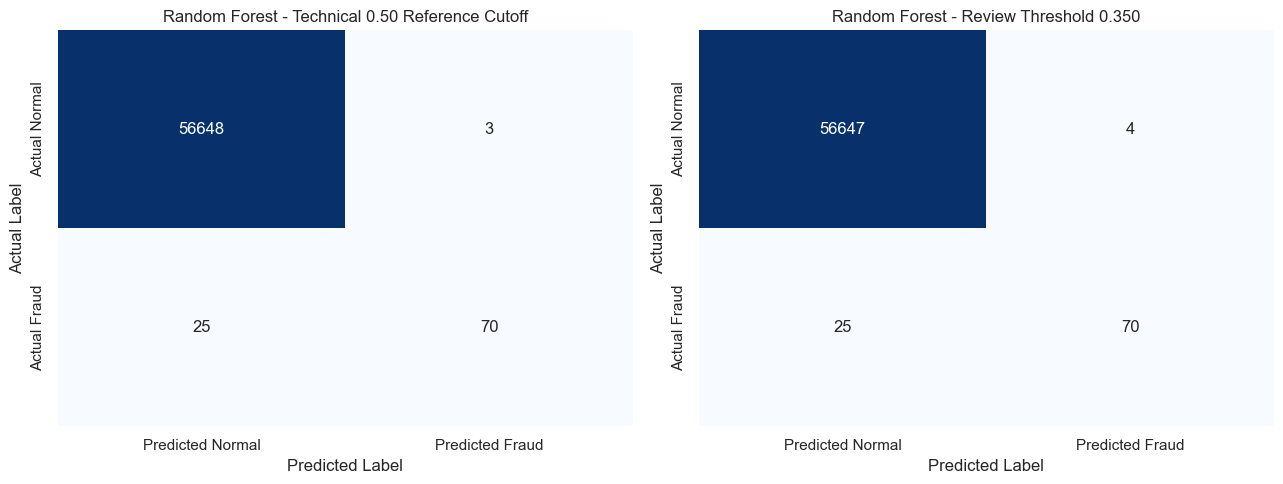

In [29]:
def plot_confusion_matrix_for_threshold(y_true: pd.Series, y_proba: pd.Series, threshold: float, ax, title: str):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Normal", "Predicted Fraud"],
        yticklabels=["Actual Normal", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix_for_threshold(
    holdout_y_true,
    holdout_y_proba_rf,
    reference_threshold,
    axes[0],
    "Random Forest - Technical 0.50 Reference Cutoff",
)
plot_confusion_matrix_for_threshold(
    holdout_y_true,
    holdout_y_proba_rf,
    review_threshold,
    axes[1],
    f"Random Forest - Review Threshold {review_threshold:.3f}",
)
fig.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The holdout/test confusion matrices show why the lower threshold should be positioned carefully. In this final evaluation, the selected review threshold catches the same number of fraud cases as the `0.50` reference cutoff, but it adds one extra false positive. That does not justify replacing `0.50` as the high-confidence fraud/BLOCK threshold.

The lower threshold remains useful as a REVIEW boundary because transactions between `0.350` and `0.50` can be routed to manual or secondary review instead of automatic blocking.


## Final Business Interpretation Table

The table below translates the selected review threshold into business language.


In [30]:
selected_precision = float(selected_row["precision"])
selected_recall = float(selected_row["recall"])
selected_f1_score = float(selected_row["f1_score"])
selected_false_positives = int(selected_row["false_positives"])
selected_false_negatives = int(selected_row["false_negatives"])
selected_frauds_caught = int(selected_row["frauds_caught"])
selected_total_alerts = int(selected_row["total_predicted_frauds"])

final_selected_precision = float(final_selected_row["precision"])
final_selected_recall = float(final_selected_row["recall"])
final_selected_f1_score = float(final_selected_row["f1_score"])
final_selected_false_positives = int(final_selected_row["false_positives"])
final_selected_false_negatives = int(final_selected_row["false_negatives"])
final_selected_frauds_caught = int(final_selected_row["frauds_caught"])
final_selected_total_alerts = int(final_selected_row["total_predicted_frauds"])

reference_frauds_caught = int(reference_row["frauds_caught"])
reference_false_positives = int(reference_row["false_positives"])
reference_false_negatives = int(reference_row["false_negatives"])
final_reference_frauds_caught = int(final_reference_row["frauds_caught"])
final_reference_false_positives = int(final_reference_row["false_positives"])
final_reference_false_negatives = int(final_reference_row["false_negatives"])

block_threshold = reference_threshold

business_interpretation = pd.DataFrame(
    [
        {
            "Metric": "Review Threshold",
            "Value": f"{review_threshold:.3f}",
            "Meaning": "Transactions at or above this probability enter REVIEW unless they also meet the BLOCK threshold.",
        },
        {
            "Metric": "Operational Block Threshold",
            "Value": f"{block_threshold:.2f}",
            "Meaning": "High-confidence fraud/BLOCK threshold retained after holdout confirmation.",
        },
        {
            "Metric": "Final Holdout/Test Recall at Review Threshold",
            "Value": f"{final_selected_recall:.2%}",
            "Meaning": "Percentage of actual fraud cases caught by the selected review threshold on holdout/test data.",
        },
        {
            "Metric": "Final Holdout/Test Precision at Review Threshold",
            "Value": f"{final_selected_precision:.2%}",
            "Meaning": "Percentage of holdout/test alerts at the review threshold that are truly fraud.",
        },
        {
            "Metric": "Final Holdout/Test False Positives at Review Threshold",
            "Value": final_selected_false_positives,
            "Meaning": "Legitimate holdout/test transactions that would enter the risky flow at the review threshold.",
        },
        {
            "Metric": "Decision Impact vs 0.50",
            "Value": (
                f"Catches {final_extra_frauds_caught:+d} more fraud cases than 0.50 "
                f"with {final_false_positives_increased:+d} additional false positives on holdout/test data."
            ),
            "Meaning": "Holdout/test confirmation does not support replacing 0.50 as the BLOCK threshold when recall does not improve.",
        },
    ]
)

display(business_interpretation)


,Metric,Value,Meaning
0,Review Threshold,0.350,Transactions at or above this probability ente...
1,Operational Block Threshold,0.50,High-confidence fraud/BLOCK threshold retained...
2,Final Holdout/Test Recall at Review Threshold,73.68%,Percentage of actual fraud cases caught by the...
3,Final Holdout/Test Precision at Review Threshold,94.59%,Percentage of holdout/test alerts at the revie...
4,Final Holdout/Test False Positives at Review T...,4,Legitimate holdout/test transactions that woul...
5,Decision Impact vs 0.50,Catches +0 more fraud cases than 0.50 with +1 ...,Holdout/test confirmation does not support rep...


### Business Interpretation

The review threshold is selected from the validation/OOF threshold-selection data and then evaluated on the holdout/test set. The holdout/test comparison shows that `0.350` should be used as a REVIEW threshold, not as the final high-confidence fraud/BLOCK threshold.

Because `0.350` catches the same number of holdout fraud cases as `0.50` while adding one false positive, the operational block threshold remains `0.50`. This keeps the final decision policy honest while preserving the lower threshold for review routing.


## Block Threshold Candidate Analysis

The review threshold is designed to catch more fraud cases. The block threshold should be stricter and should prioritize high precision because automatic blocking has stronger customer and business consequences.

The table below searches for candidate block thresholds using these rules:

- threshold must be strictly greater than the selected review threshold
- precision must be at least `0.90`
- recall must be at least `0.60`

For the block threshold candidate, precision is prioritized because false positives at the `BLOCK` stage have stronger business impact than false positives at the `REVIEW` stage. Recall and F1-score are still reviewed so the block candidate remains meaningful, but the main requirement is a cleaner, higher-confidence risk zone.

In [31]:
block_candidates = threshold_evaluation.loc[
    (threshold_evaluation["threshold"] > review_threshold) &
    (threshold_evaluation["precision"] >= 0.90) &
    (threshold_evaluation["recall"] >= 0.60)
].copy()

block_candidates = block_candidates.sort_values(
    by=["precision", "recall", "f1_score", "false_positives"],
    ascending=[False, False, False, True],
)

if len(block_candidates) > 0:
    block_threshold_candidate_row = block_candidates.iloc[0]
    block_threshold_candidate = float(block_threshold_candidate_row["threshold"])
    block_threshold_status = "candidate_requires_business_validation"
else:
    fallback_candidates = threshold_evaluation.loc[
        threshold_evaluation["threshold"] > review_threshold
    ].copy()

    if len(fallback_candidates) > 0:
        fallback_candidates = fallback_candidates.sort_values(
            by=["precision", "threshold"],
            ascending=[False, True],
        )
        block_threshold_candidate_row = fallback_candidates.iloc[0]
        block_threshold_candidate = float(block_threshold_candidate_row["threshold"])
        block_threshold_status = "fallback_highest_precision_above_review_threshold"
    else:
        block_threshold_candidate_row = None
        block_threshold_candidate = None
        block_threshold_status = "not_available"

if block_threshold_candidate is not None:
    block_threshold_candidate_holdout_row = final_holdout_threshold_evaluation.loc[
        np.isclose(final_holdout_threshold_evaluation["threshold"], block_threshold_candidate)
    ].iloc[0]
else:
    block_threshold_candidate_holdout_row = None

block_candidate_display = block_candidates.head(10).copy()
if block_candidate_display.empty and block_threshold_candidate_row is not None:
    block_candidate_display = pd.DataFrame([block_threshold_candidate_row.to_dict()])

display(block_candidate_display)
if block_threshold_candidate is not None:
    print(f"Recommended block threshold candidate: {block_threshold_candidate:.3f}")
else:
    print("Recommended block threshold candidate: not available")
print(f"Block threshold status: {block_threshold_status}")

,threshold_selection_source,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
820,validation_or_oof,0.821000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
821,validation_or_oof,0.822000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
822,validation_or_oof,0.823000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
823,validation_or_oof,0.824000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
824,validation_or_oof,0.825000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
825,validation_or_oof,0.826000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
826,validation_or_oof,0.827000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
827,validation_or_oof,0.828000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
828,validation_or_oof,0.829000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243
829,validation_or_oof,0.830000,0.958848,0.616402,0.750403,0.999317,233,10,226592,145,233,145,243


Recommended block threshold candidate: 0.821
Block threshold status: candidate_requires_business_validation


In [32]:
if block_threshold_candidate is not None:
    block_threshold_message = (
        f"The block threshold candidate is `{block_threshold_candidate:.3f}`. "
        f"It is greater than the review threshold `{review_threshold:.3f}`, which preserves valid APPROVE, REVIEW, and BLOCK decision zones."
    )
else:
    block_threshold_message = (
        "No reliable block threshold candidate was found above the review threshold using the current criteria. "
        "Automatic BLOCK should use the confirmed 0.50 threshold unless a separate candidate is validated and approved."
    )

display(Markdown(f"""
### Block Threshold Candidate Interpretation

{block_threshold_message}

This candidate is not the operational block threshold in this notebook. The operational block threshold remains `0.50` unless the candidate is proven better on holdout/test data and a business cost analysis supports the trade-off. Automatic blocking can affect legitimate customers, so any stricter or alternate block threshold should be reviewed with customer-friction tolerance, fraud-loss cost, and policy requirements in notebook `16_decision_logic.ipynb`.
"""))



### Block Threshold Candidate Interpretation

The block threshold candidate is `0.821`. It is greater than the review threshold `0.350`, which preserves valid APPROVE, REVIEW, and BLOCK decision zones.

This candidate is not the operational block threshold in this notebook. The operational block threshold remains `0.50` unless the candidate is proven better on holdout/test data and a business cost analysis supports the trade-off. Automatic blocking can affect legitimate customers, so any stricter or alternate block threshold should be reviewed with customer-friction tolerance, fraud-loss cost, and policy requirements in notebook `16_decision_logic.ipynb`.


## Final Holdout Threshold Recommendation Table

This table compares the default `0.50` threshold, the validation/OOF-selected `0.350` threshold, and the block threshold candidate if one is available. The comparison uses holdout/test metrics only for confirmation, not for threshold tuning.


In [33]:
def make_final_recommendation_row(row: pd.Series, threshold_purpose: str, final_recommendation: str) -> dict:
    return {
        "threshold": float(row["threshold"]),
        "threshold_purpose": threshold_purpose,
        "true_positives": int(row["true_positives"]),
        "false_positives": int(row["false_positives"]),
        "false_negatives": int(row["false_negatives"]),
        "true_negatives": int(row["true_negatives"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "frauds_caught": int(row["frauds_caught"]),
        "false_positive_increase_vs_050": int(row["false_positives"] - final_reference_row["false_positives"]),
        "recall_gain_vs_050": float(row["recall"] - final_reference_row["recall"]),
        "final_recommendation": final_recommendation,
    }

final_recommendation_rows = [
    make_final_recommendation_row(
        final_reference_row,
        "Default high-confidence fraud/block threshold",
        "Keep as high-confidence fraud/block threshold",
    ),
    make_final_recommendation_row(
        final_selected_row,
        "Validation/OOF selected lower review threshold",
        "Use only as review threshold",
    ),
]

if block_threshold_candidate_holdout_row is not None:
    final_recommendation_rows.append(
        make_final_recommendation_row(
            block_threshold_candidate_holdout_row,
            "Block threshold candidate from validation/OOF tuning",
            "Candidate for block threshold if business accepts tradeoff",
        )
    )

final_threshold_recommendation_table = pd.DataFrame(final_recommendation_rows)
display(final_threshold_recommendation_table)
print(f"Final operational review_threshold: {review_threshold:.3f}")
print(f"Final operational block_threshold: {block_threshold:.2f}")
print(f"Holdout-aware recommendation: {holdout_threshold_recommendation}")


,threshold,threshold_purpose,true_positives,false_positives,false_negatives,true_negatives,precision,recall,f1_score,frauds_caught,false_positive_increase_vs_050,recall_gain_vs_050,final_recommendation
0,0.500000,Default high-confidence fraud/block threshold,70,3,25,56648,0.958904,0.736842,0.833333,70,0,0.000000,Keep as high-confidence fraud/block threshold
1,0.350000,Validation/OOF selected lower review threshold,70,4,25,56647,0.945946,0.736842,0.828402,70,1,0.000000,Use only as review threshold
2,0.821000,Block threshold candidate from validation/OOF ...,59,1,36,56650,0.983333,0.621053,0.761290,59,-2,-0.115789,Candidate for block threshold if business acce...


Final operational review_threshold: 0.350
Final operational block_threshold: 0.50
Holdout-aware recommendation: Selected threshold does not improve holdout recall and adds false positives; do not replace 0.50 as final block threshold. Use it only as REVIEW threshold.


## Save Selected Threshold Artifact

The saved JSON artifact separates the review threshold from the operational block threshold. It also records the holdout confirmation result so downstream notebooks do not mistake the validation/OOF-selected review threshold for a final automatic-blocking threshold.


In [34]:
threshold_order_valid = block_threshold > review_threshold

if block_threshold <= review_threshold:
    raise ValueError(
        "Invalid threshold configuration: block_threshold must be greater than review_threshold. "
        f"Got review_threshold={review_threshold:.3f}, block_threshold={block_threshold:.3f}."
    )

if block_threshold_candidate is not None and block_threshold_candidate <= review_threshold:
    raise ValueError(
        "Invalid threshold configuration: block_threshold_candidate must be greater than review_threshold. "
        f"Got review_threshold={review_threshold:.3f}, "
        f"block_threshold_candidate={block_threshold_candidate:.3f}."
    )

block_selection_metrics = {}
block_holdout_metrics = {}
if block_threshold_candidate_row is not None:
    block_selection_metrics = {
        "block_threshold_candidate_selection_precision": float(block_threshold_candidate_row["precision"]),
        "block_threshold_candidate_selection_recall": float(block_threshold_candidate_row["recall"]),
        "block_threshold_candidate_selection_f1_score": float(block_threshold_candidate_row["f1_score"]),
    }
if block_threshold_candidate_holdout_row is not None:
    block_holdout_metrics = {
        "block_threshold_candidate_holdout_precision": float(block_threshold_candidate_holdout_row["precision"]),
        "block_threshold_candidate_holdout_recall": float(block_threshold_candidate_holdout_row["recall"]),
        "block_threshold_candidate_holdout_false_positives": int(block_threshold_candidate_holdout_row["false_positives"]),
        "block_threshold_candidate_holdout_false_negatives": int(block_threshold_candidate_holdout_row["false_negatives"]),
    }

holdout_confirmation_reason = (
    "Selected threshold caught the same fraud cases as 0.50 on holdout but introduced additional false positives."
    if selected_tp == default_tp and selected_fp > default_fp
    else holdout_threshold_recommendation
)

selected_threshold_payload = {
    "model_name": MODEL_NAME,
    "selected_threshold": selected_threshold,
    "review_threshold": review_threshold,
    "block_threshold": block_threshold,
    "block_threshold_candidate": block_threshold_candidate,
    "threshold_role": "review_threshold",
    "block_threshold_status": "operational_default_0.50_with_candidate_requiring_business_validation",
    "threshold_selection_source": threshold_source,
    "threshold_selection_path": str(threshold_selection_path.relative_to(PROJECT_ROOT)),
    "threshold_order_valid": threshold_order_valid,
    "holdout_confirmation": {
        "selected_threshold_replaced_default": selected_threshold_replaced_default,
        "reason": holdout_confirmation_reason,
    },
    "decision_policy": {
        "APPROVE": "fraud_probability < review_threshold",
        "REVIEW": "review_threshold <= fraud_probability < block_threshold",
        "BLOCK": "fraud_probability >= block_threshold",
    },
    "note": (
        "Review threshold is selected for REVIEW decision boundary. Operational BLOCK uses 0.50 because holdout/test confirmation "
        "did not support replacing the default high-confidence threshold. Block threshold candidate is preserved only as a candidate "
        "unless holdout evidence and business cost analysis support it."
    ),
    "selection_reason": selected_threshold_reason,
    "holdout_threshold_recommendation": holdout_threshold_recommendation,
    "selection_precision": selected_precision,
    "selection_recall": selected_recall,
    "selection_f1_score": selected_f1_score,
    "selection_false_positives": selected_false_positives,
    "selection_false_negatives": selected_false_negatives,
    "selection_frauds_caught": selected_frauds_caught,
    "selection_total_predicted_frauds": selected_total_alerts,
    "final_holdout_precision": final_selected_precision,
    "final_holdout_recall": final_selected_recall,
    "final_holdout_f1_score": final_selected_f1_score,
    "final_holdout_false_positives": final_selected_false_positives,
    "final_holdout_false_negatives": final_selected_false_negatives,
    "final_holdout_frauds_caught": final_selected_frauds_caught,
    "final_holdout_total_predicted_frauds": final_selected_total_alerts,
    "final_recall_message": final_recall_message,
    "reference_threshold": reference_threshold,
    "reference_threshold_role": "operational_high_confidence_fraud_block_threshold",
    "final_reference_frauds_caught": final_reference_frauds_caught,
    "final_reference_false_positives": final_reference_false_positives,
    "final_reference_false_negatives": final_reference_false_negatives,
    "final_extra_frauds_caught_vs_reference": final_extra_frauds_caught,
    "final_false_negatives_reduced_vs_reference": final_false_negatives_reduced,
    "final_false_positives_increased_vs_reference": final_false_positives_increased,
    "final_precision_difference_vs_reference": final_precision_difference,
    "final_recall_difference_vs_reference": final_recall_difference,
    "final_f1_score_difference_vs_reference": final_f1_difference,
    **block_selection_metrics,
    **block_holdout_metrics,
}

SELECTED_THRESHOLD_FILE.write_text(json.dumps(selected_threshold_payload, indent=2), encoding="utf-8")
print(f"Saved selected threshold artifact to: {SELECTED_THRESHOLD_FILE}")
print(json.dumps(selected_threshold_payload, indent=2))


Saved selected threshold artifact to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json
{
  "model_name": "Random Forest",
  "selected_threshold": 0.35,
  "review_threshold": 0.35,
  "block_threshold": 0.5,
  "block_threshold_candidate": 0.821,
  "threshold_role": "review_threshold",
  "block_threshold_status": "operational_default_0.50_with_candidate_requiring_business_validation",
  "threshold_selection_source": "validation_or_oof",
  "threshold_selection_path": "reports/tables/13_model_training/cv_oof_predictions.csv",
  "threshold_order_valid": true,
  "holdout_confirmation": {
    "selected_threshold_replaced_default": false,
    "reason": "Selected threshold caught the same fraud cases as 0.50 on holdout but introduced additional false positives."
  },
  "decision_policy": {
    "APPROVE": "fraud_probability < review_threshold",
    "REVIEW": "review_threshold <= fraud_probability < block_threshold",
    "BLOCK": "fraud_probability >= blo

### Saved Artifact Interpretation

The JSON artifact records separate `review_threshold` and `block_threshold` values. The review threshold is the validation/OOF-selected lower investigation boundary, while the operational block threshold remains `0.50` after holdout confirmation.

If `block_threshold_candidate` is available, it is preserved as a candidate only. It should not replace the operational block threshold unless holdout/test evidence and business cost analysis support that change.


## Why F1 Alone Is Not Enough for Fraud Threshold Selection

F1 is useful because it summarizes precision and recall, but fraud systems are business decision systems. A lower threshold is only better if the additional fraud caught is worth the extra false positives it creates.

If recall does not improve and false positives increase, the lower threshold should not replace the default threshold for high-confidence fraud blocking. That is what the holdout/test confirmation shows here for `0.350` versus `0.50`.

A future cost-based analysis should add explicit assumptions for:

- cost of missed fraud
- cost of manual review
- cost of blocking a legitimate customer


In [35]:
display(Markdown(f"""
## Final Conclusion

Validation/OOF tuning selected `{review_threshold:.3f}` as a useful lower review threshold. However, final holdout evaluation did not support replacing the default `0.50` high-confidence fraud threshold because `{review_threshold:.3f}` caught the same number of fraud cases while adding one additional false positive. Therefore, the final operational recommendation is to use `{review_threshold:.3f}` as the REVIEW threshold and `0.50` as the BLOCK/high-confidence fraud threshold.

The block threshold candidate is preserved for analysis, but it is not the operational block threshold unless later holdout evidence and business cost analysis support that change.
"""))



## Final Conclusion

Validation/OOF tuning selected `0.350` as a useful lower review threshold. However, final holdout evaluation did not support replacing the default `0.50` high-confidence fraud threshold because `0.350` caught the same number of fraud cases while adding one additional false positive. Therefore, the final operational recommendation is to use `0.350` as the REVIEW threshold and `0.50` as the BLOCK/high-confidence fraud threshold.

The block threshold candidate is preserved for analysis, but it is not the operational block threshold unless later holdout evidence and business cost analysis support that change.


## Connection to Next Notebook: Decision Logic

In the next notebook, use the validation/OOF-selected threshold as the review threshold and keep the confirmed default threshold as the operational block threshold.

```python
review_threshold = 0.350
block_threshold = 0.50

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

Decision meanings:

- `APPROVE`: probability below review threshold
- `REVIEW`: probability between review threshold and block threshold
- `BLOCK`: probability above block threshold

If `block_threshold_candidate` is available, keep it as an analysis candidate only until holdout/test evidence and business cost analysis justify replacing `0.50`.

Next Step: `16_decision_logic.ipynb`
